## Step 1: Problem Definition & Objective Setting
**Objective:** Predict property prices (Price or LogPrice) using features like Area, BHK, Facilities, and location data.

**Type of ML task:** Supervised Regression

**Target variable:** Price (or LogPrice if using log transformation to normalize skew)



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import numpy as np

In [7]:
df = pd.read_csv("final_data_for_project.csv")

## Step 2: Initial Dataset Structure
**Dataset Size:** 1139 entries (rows), 30 columns (features).

**Target Variable:** Price

**Feature Types:**

`int64`: 22 columns (e.g., `BHK`, `Bathrooms`, `Lift`, etc.) \
`float64`: 8 columns (e.g., `Area`, `Floor`, `Latitude`, etc.)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1139 entries, 0 to 1138
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   BHK                    1139 non-null   int64  
 1   Price                  1139 non-null   float64
 2   Area                   1139 non-null   float64
 3   Bathrooms              1139 non-null   int64  
 4   Balcony                1139 non-null   int64  
 5   Floor                  1139 non-null   float64
 6   Total Floors           1139 non-null   float64
 7   Store_Room             1139 non-null   int64  
 8   Study_Room             1139 non-null   int64  
 9   Pooja_Room             1139 non-null   int64  
 10  Servant_Room           1139 non-null   int64  
 11  Property_Age_Years     1139 non-null   float64
 12  Area_Type_Encoded      1139 non-null   int64  
 13  Furnishing_Level_Code  1139 non-null   int64  
 14  Facility_Premium       1139 non-null   int64  
 15  Lift

##  Step 3: Exploratory Data Analysis (EDA)

In [10]:
# Set default style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### UNIVARIATE ANALYSIS

#### 1. Continuous Features - Histograms & KDE

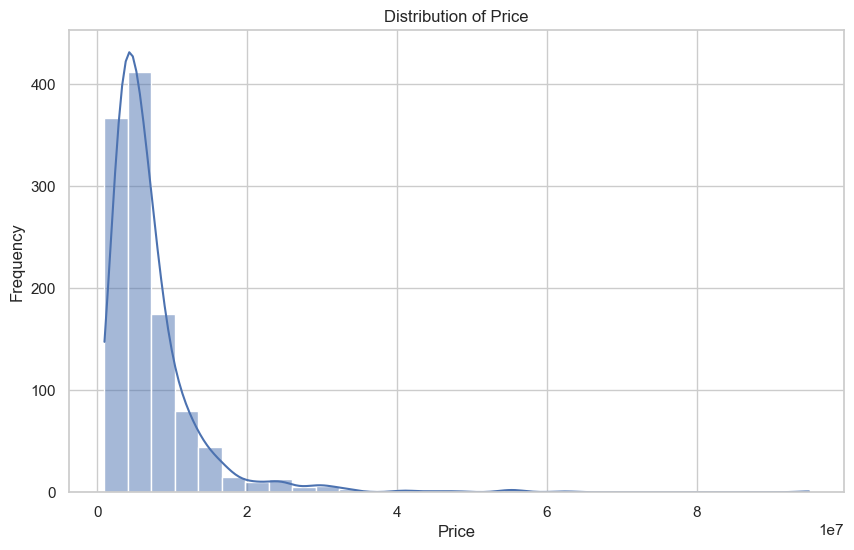

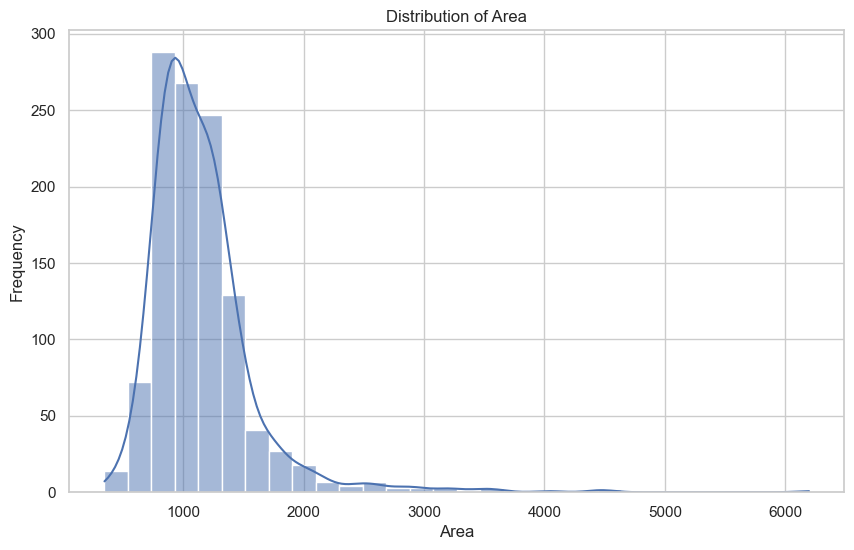

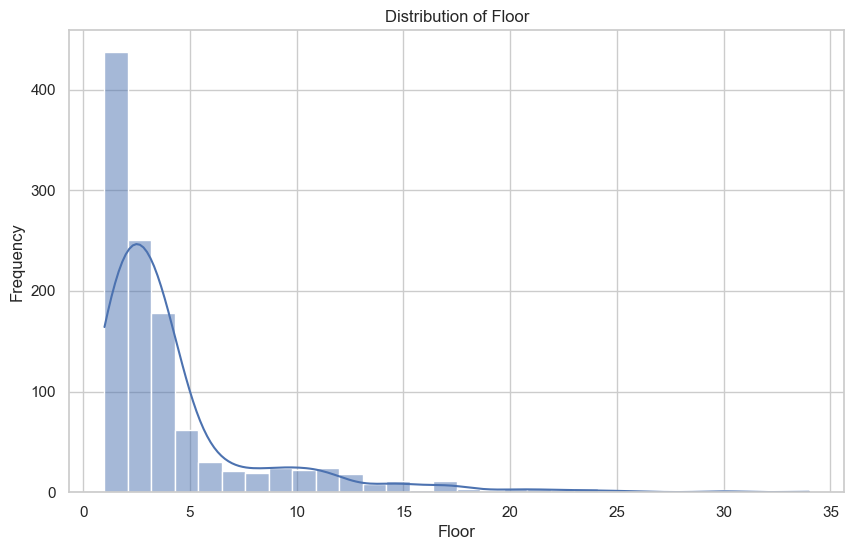

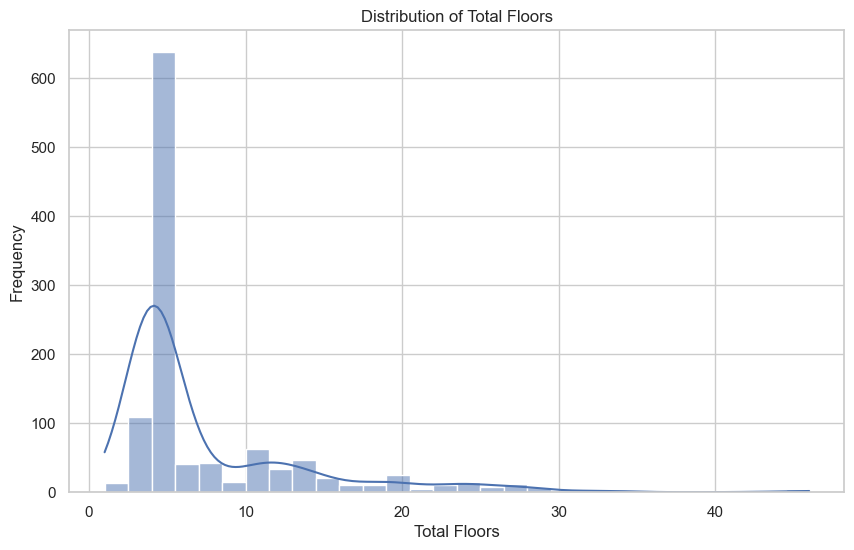

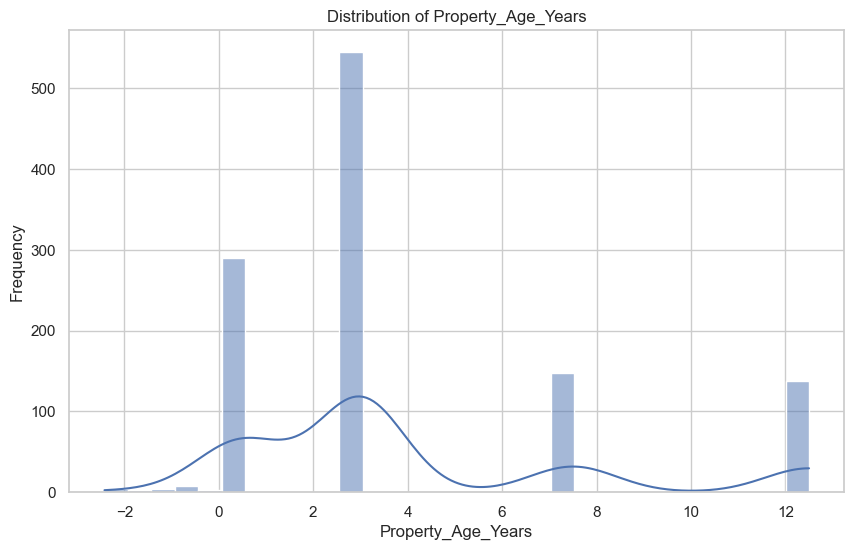

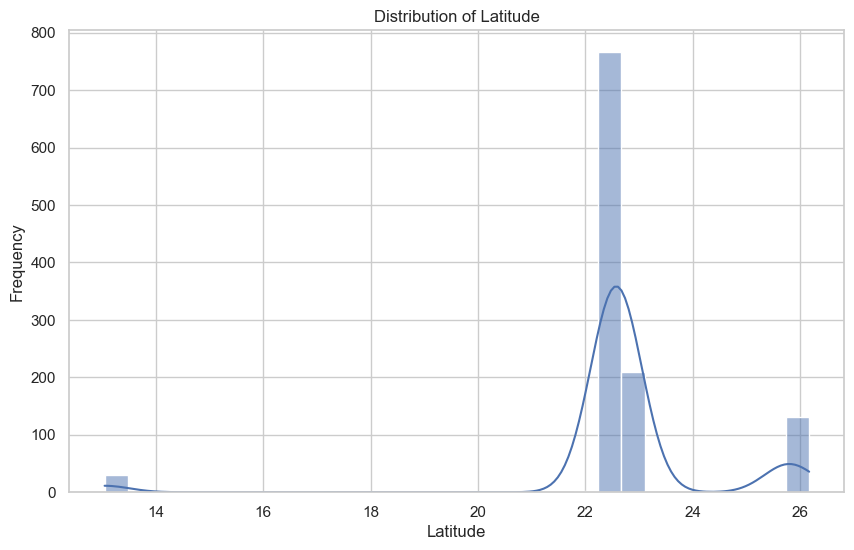

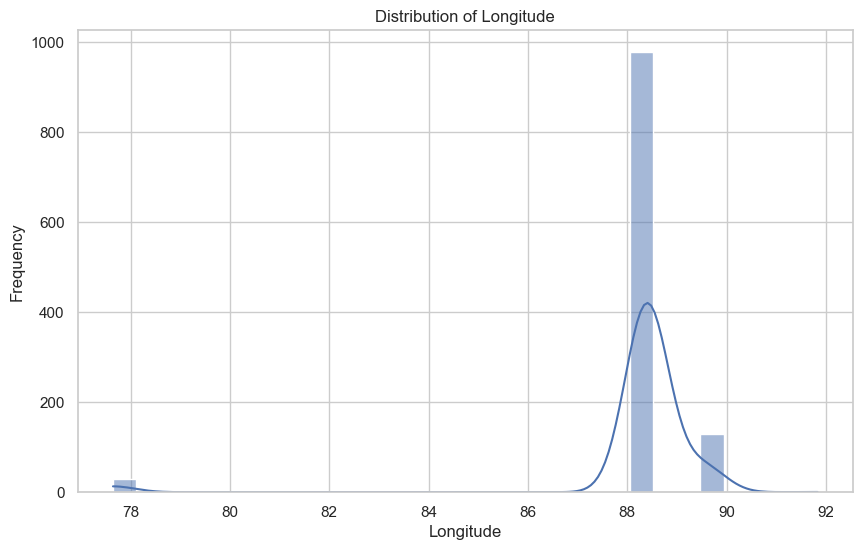

In [11]:
continuous_cols = ['Price', 'Area', 'Floor', 'Total Floors', 'Property_Age_Years', 'Latitude', 'Longitude']

for col in continuous_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

#### 2. Categorical/Binary Features - Bar Plots

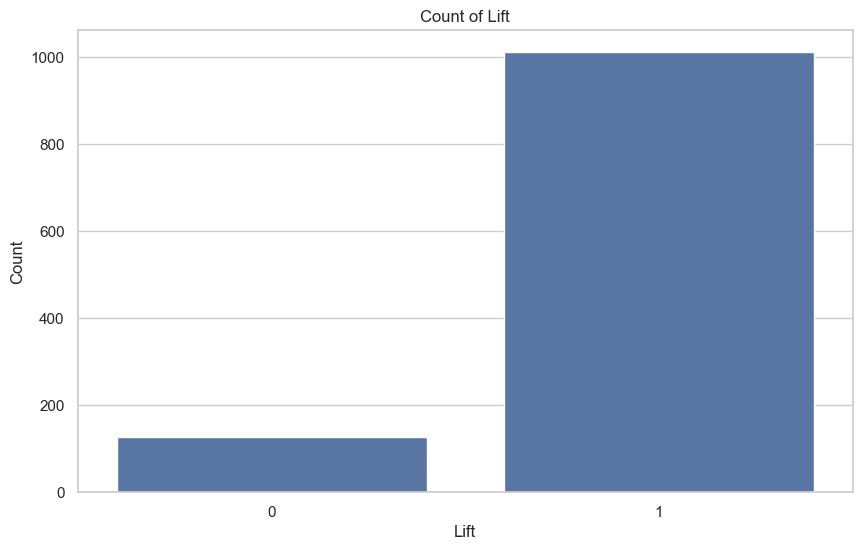

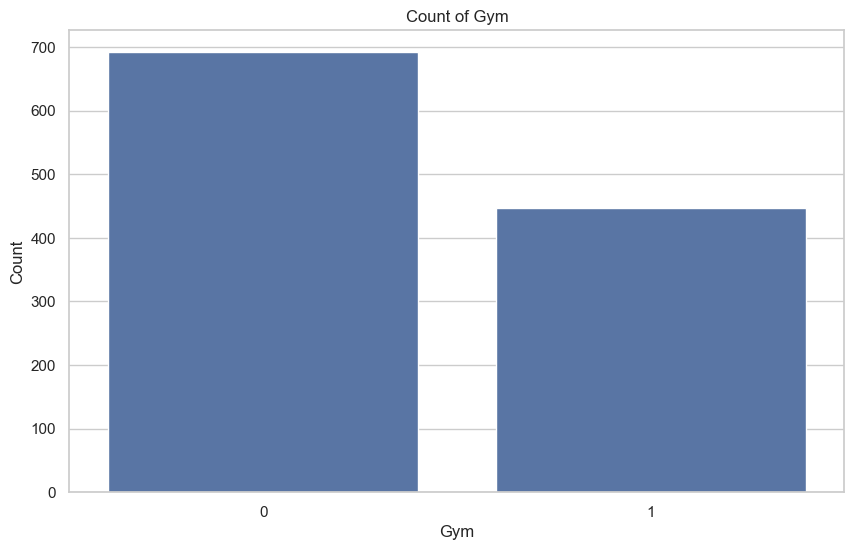

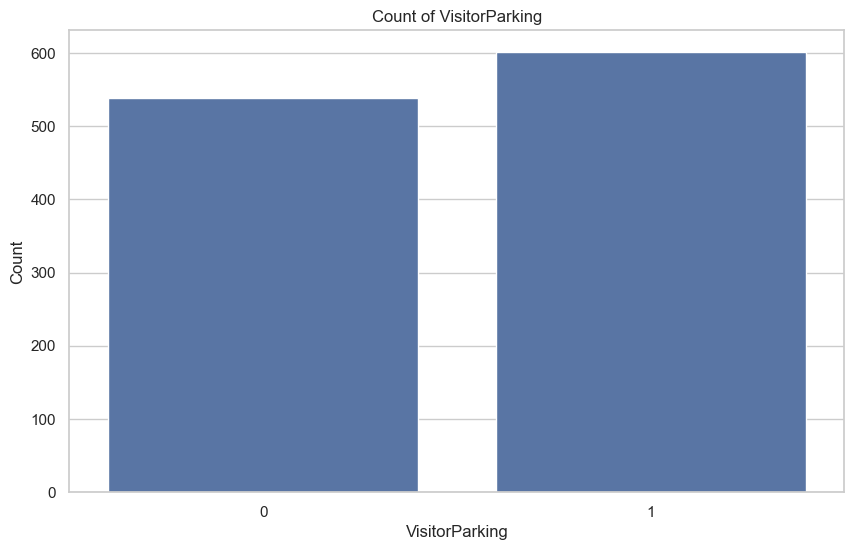

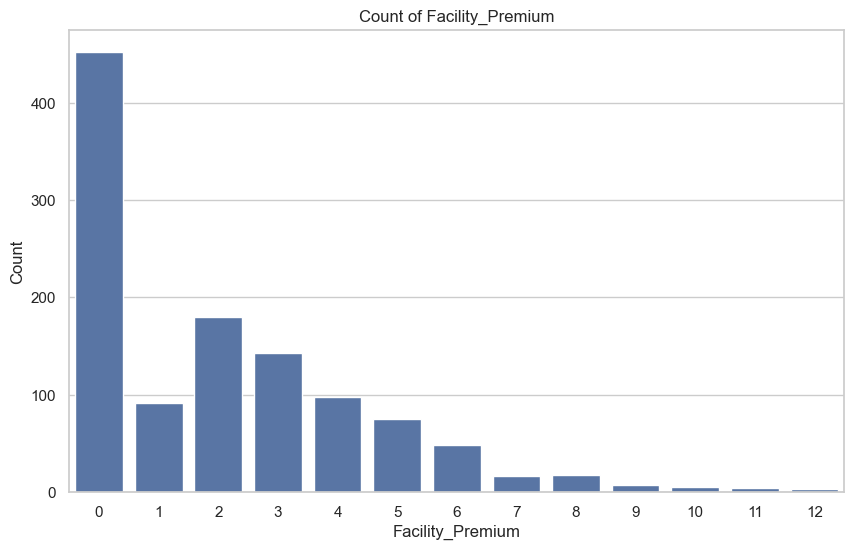

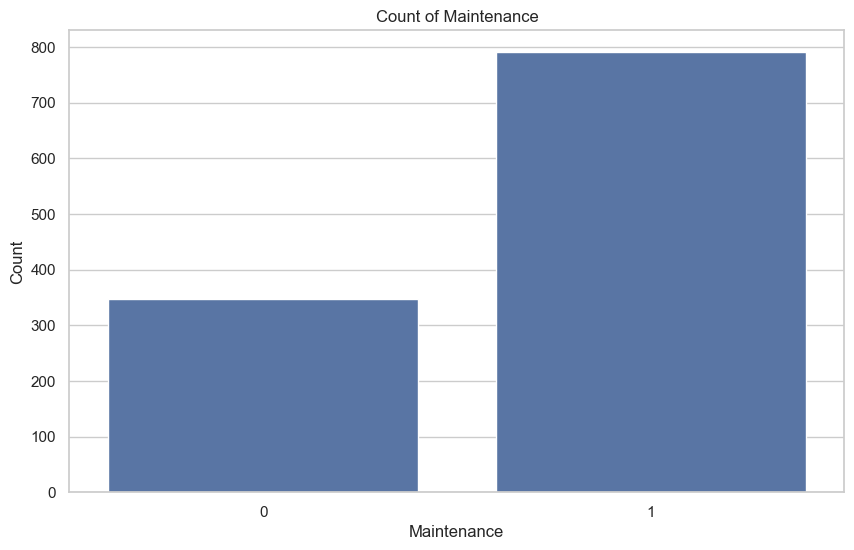

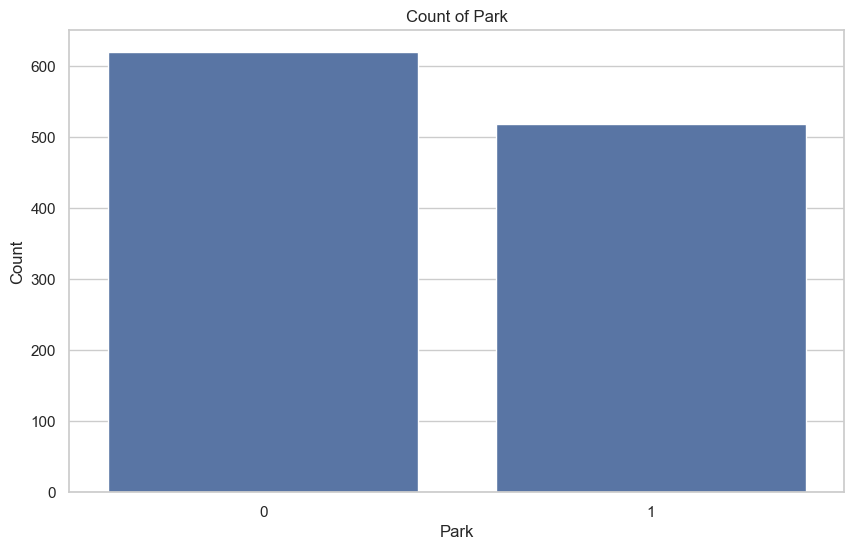

In [12]:
binary_cols = ['Lift', 'Gym', 'VisitorParking', 'Facility_Premium', 'Maintenance', 'Park']

for col in binary_cols:
    plt.figure()
    sns.countplot(x=col, data=df)
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

#### 3. Boxplots for Outlier Detection

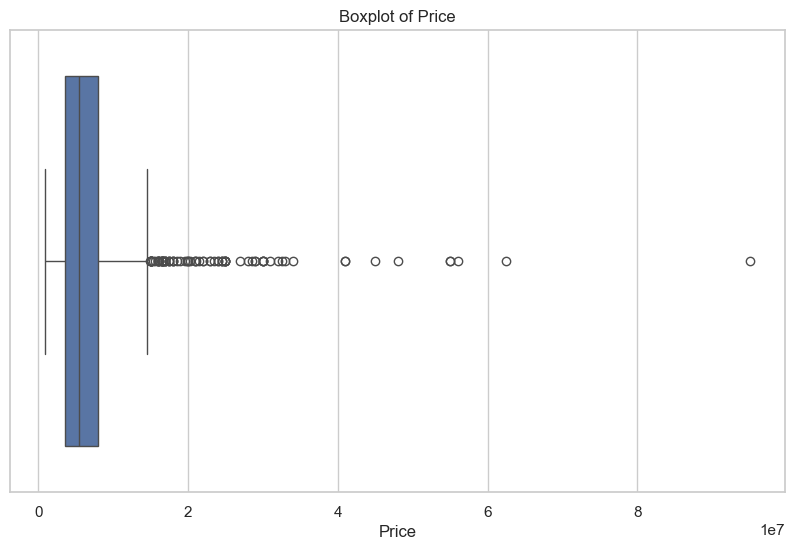

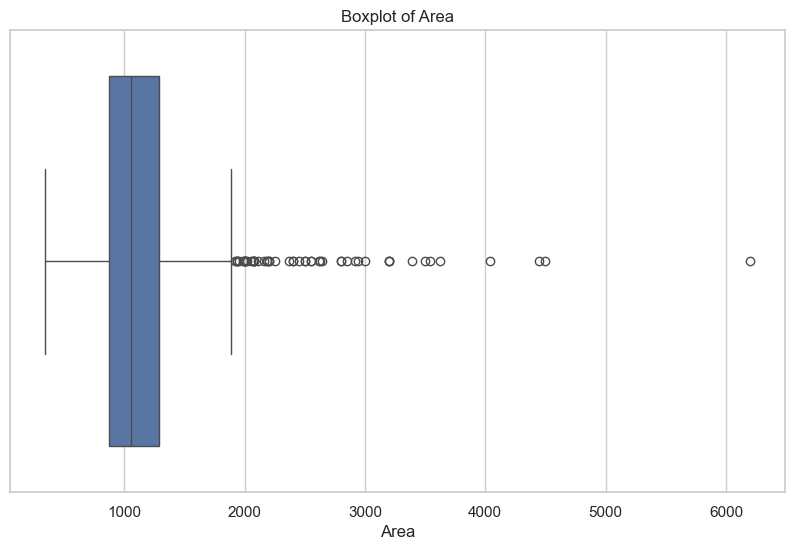

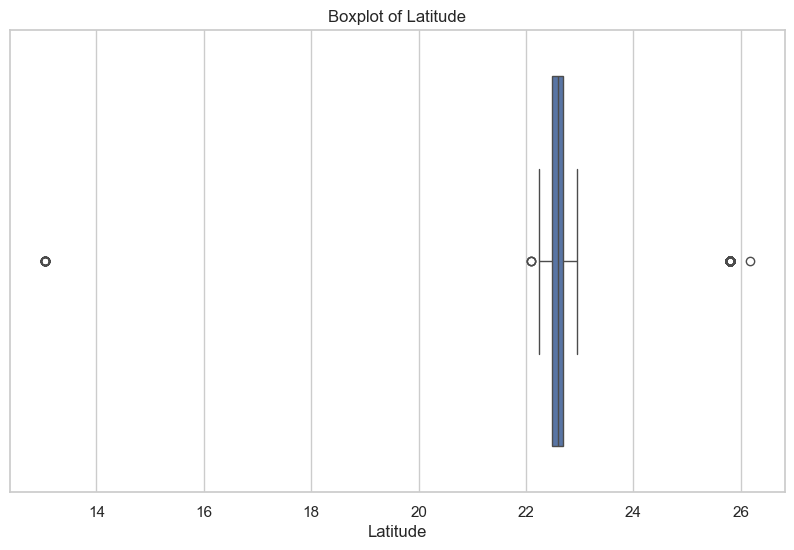

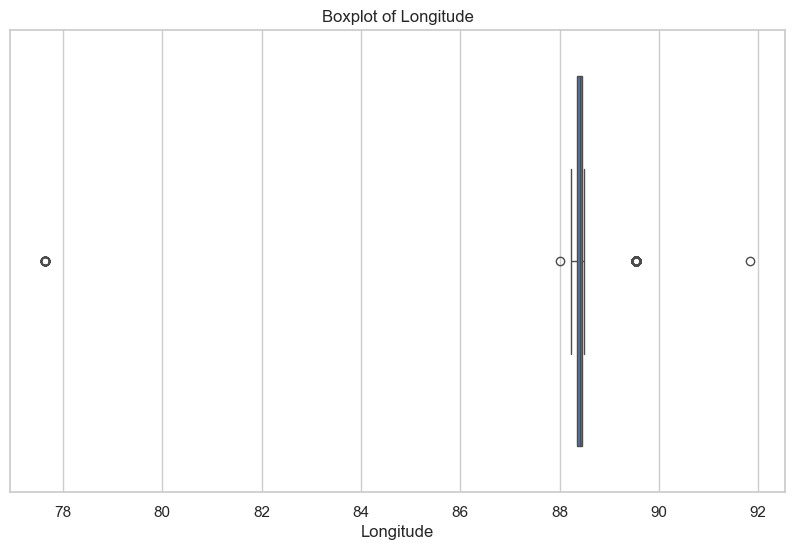

In [13]:
for col in ['Price', 'Area', 'Latitude', 'Longitude']:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

#### 4. Value Counts for Discrete Variables

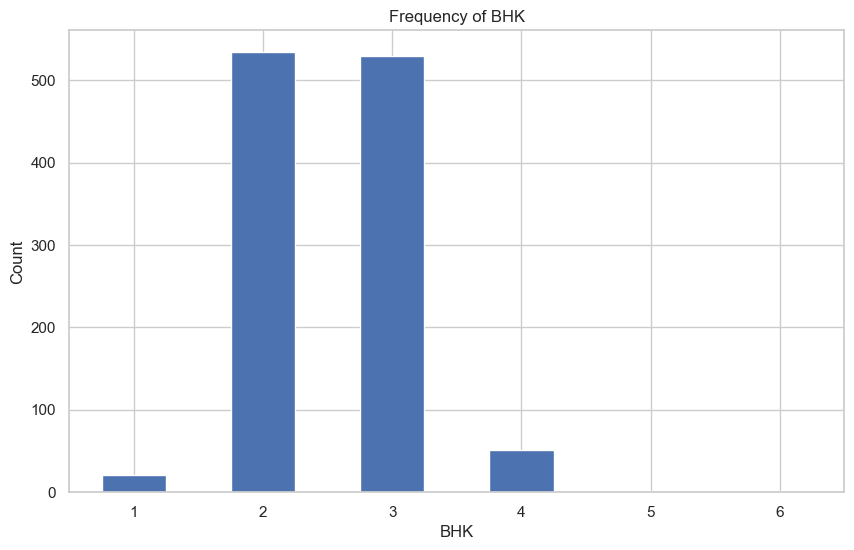

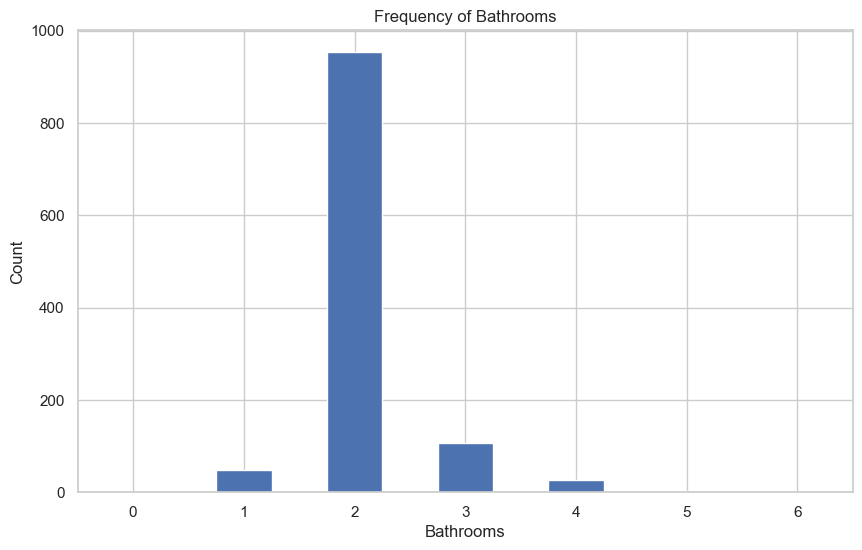

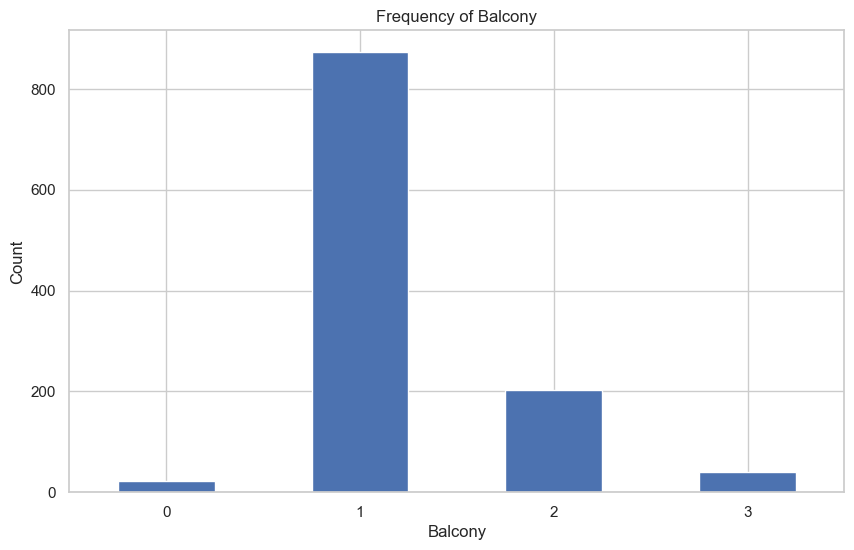

In [14]:
discrete_cols = ['BHK', 'Bathrooms', 'Balcony']

for col in discrete_cols:
    plt.figure()
    df[col].value_counts().sort_index().plot(kind='bar')
    plt.title(f"Frequency of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

###  MULTIVARIATE ANALYSIS

#### 5. Heatmap of Pearson Correlation

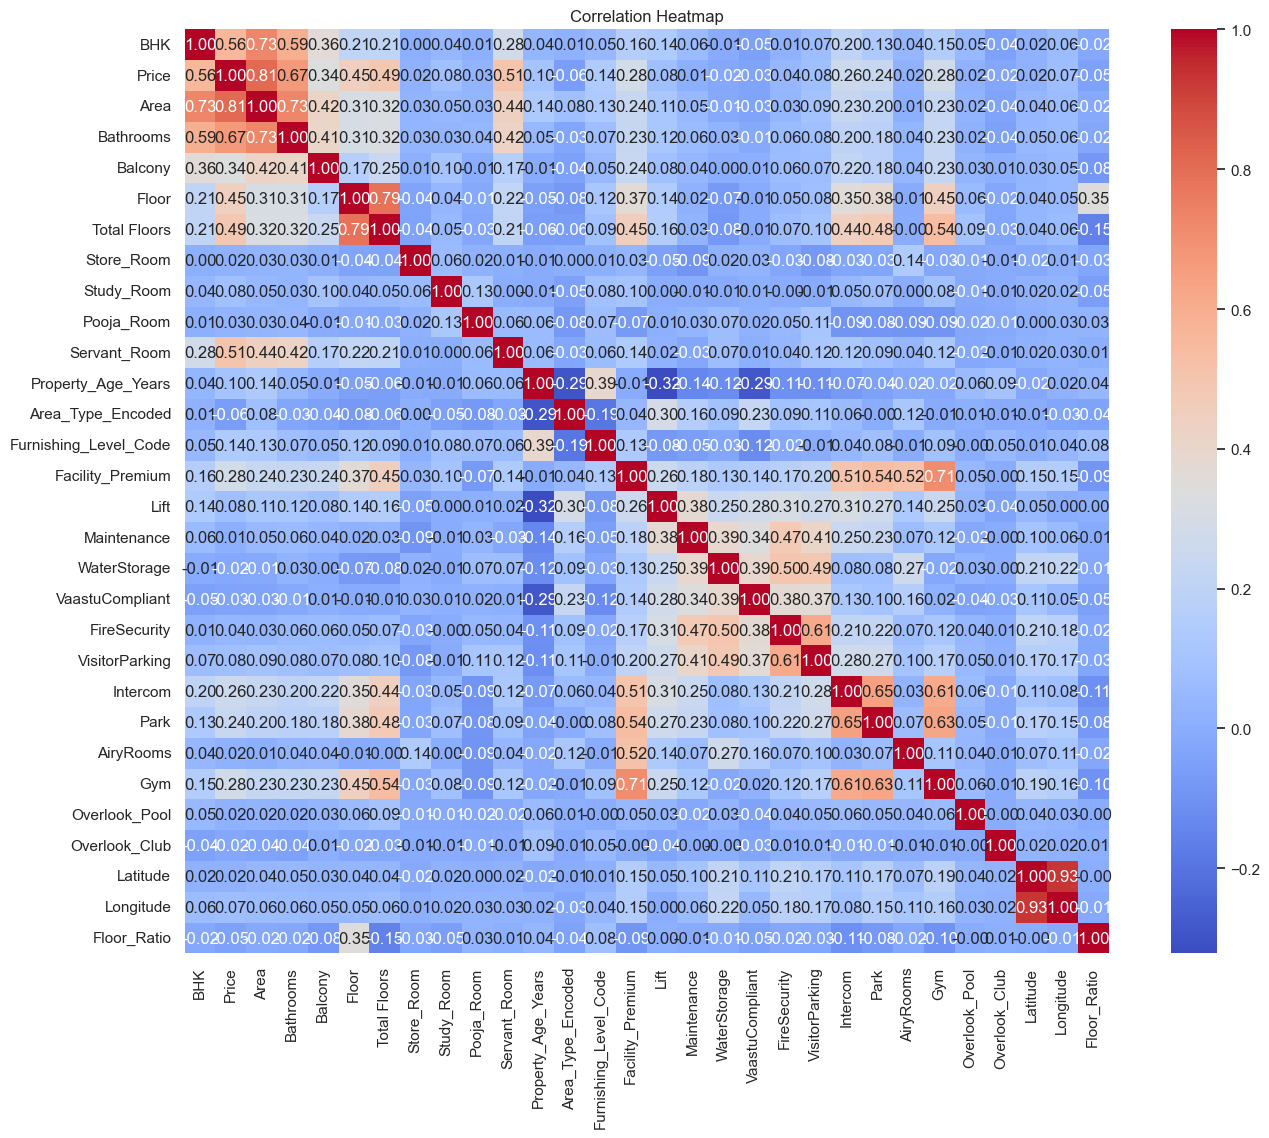

In [15]:
plt.figure(figsize=(16, 12))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.show()

#### 6. Scatter Plots

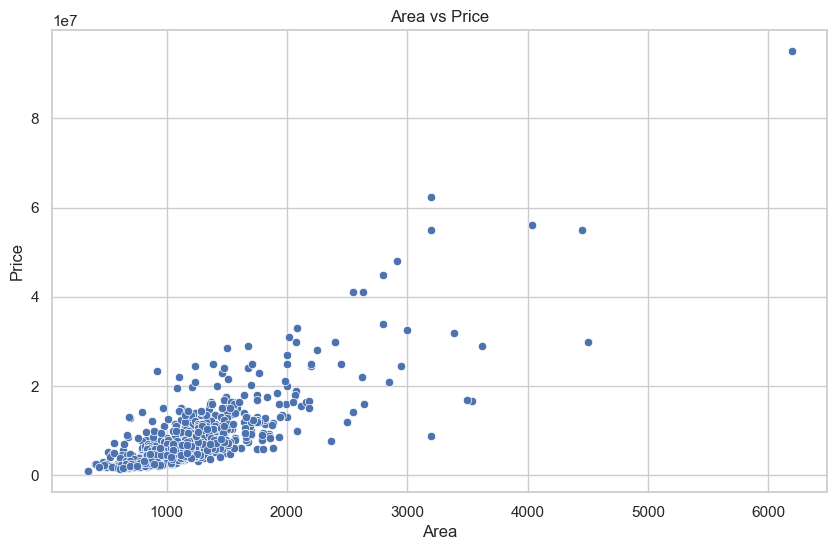

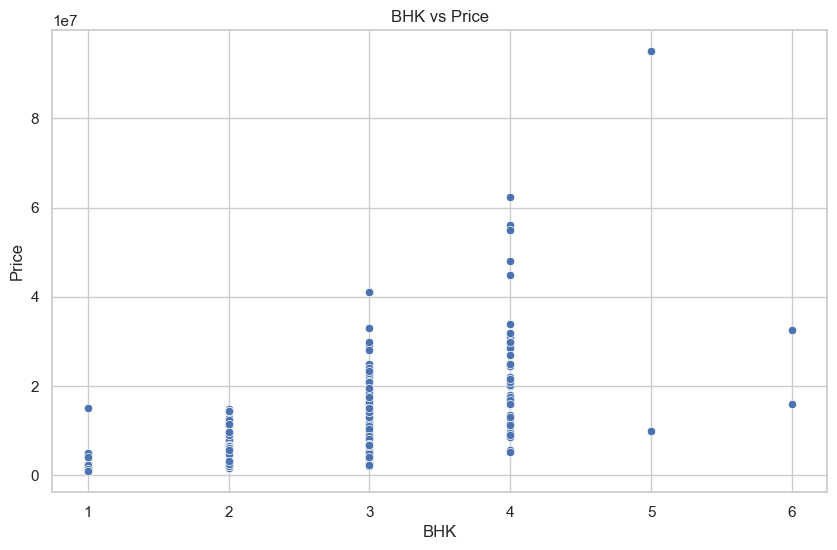

In [16]:
scatter_features = ['Area', 'BHK']

for col in scatter_features:
    plt.figure()
    sns.scatterplot(x=df[col], y=df['Price'])
    plt.title(f"{col} vs Price")
    plt.xlabel(col)
    plt.ylabel("Price")
    plt.show()

#### 7. Boxplots grouped by category

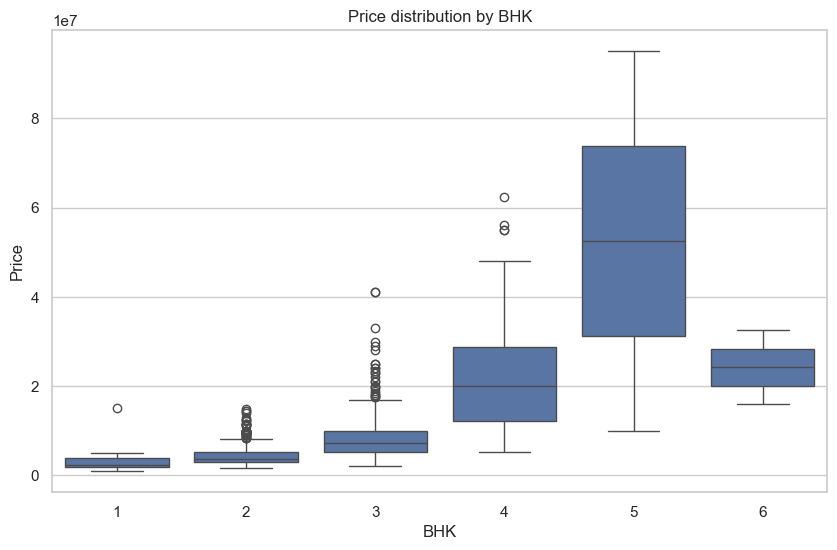

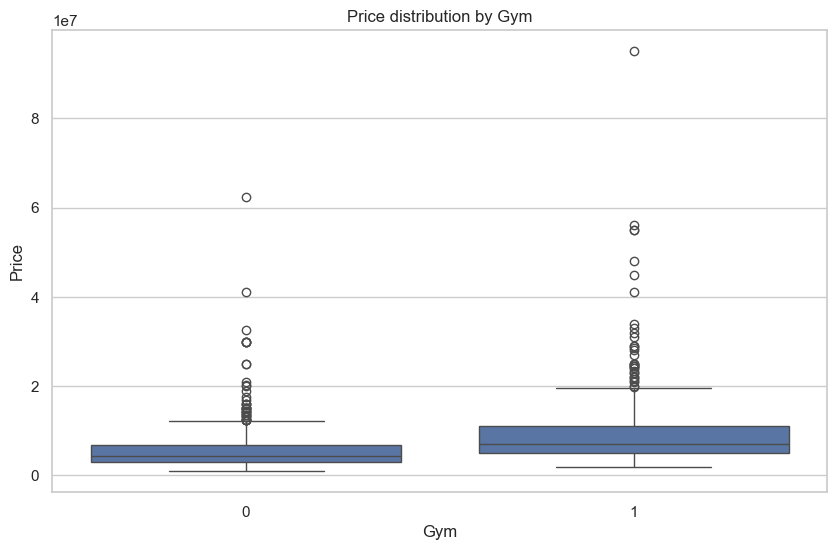

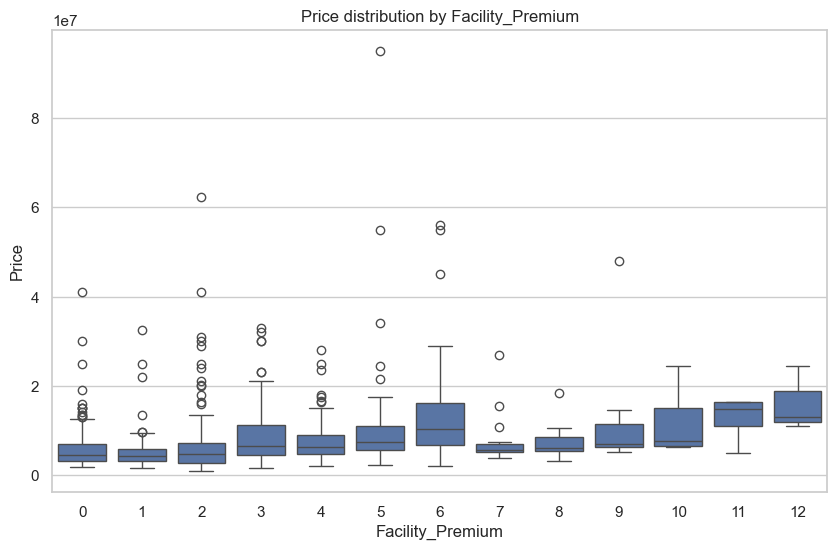

In [17]:
boxplot_features = ['BHK', 'Gym', 'Facility_Premium']

for col in boxplot_features:
    plt.figure()
    sns.boxplot(x=col, y='Price', data=df)
    plt.title(f"Price distribution by {col}")
    plt.xlabel(col)
    plt.ylabel("Price")
    plt.show()

In [19]:
# 8. Optional: Pairplot (heavy, use with caution)
# sns.pairplot(df[['Price', 'Area', 'BHK', 'Bathrooms']])
# plt.show()

###  ADDITIONAL INSIGHTS

#### 9. Log-transform check

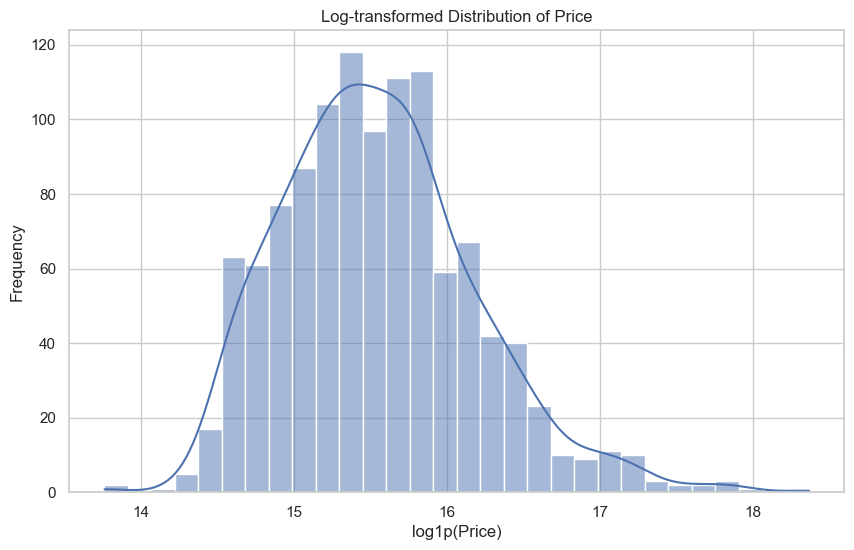

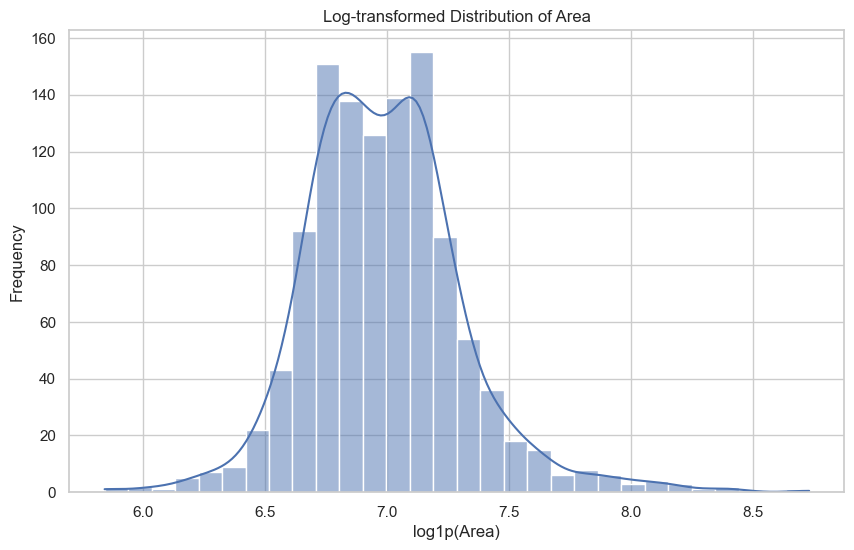

In [20]:
log_cols = ['Price', 'Area']
for col in log_cols:
    plt.figure()
    sns.histplot(np.log1p(df[col]), kde=True, bins=30)
    plt.title(f"Log-transformed Distribution of {col}")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Frequency")
    plt.show()

#### 10. Location Heatmap

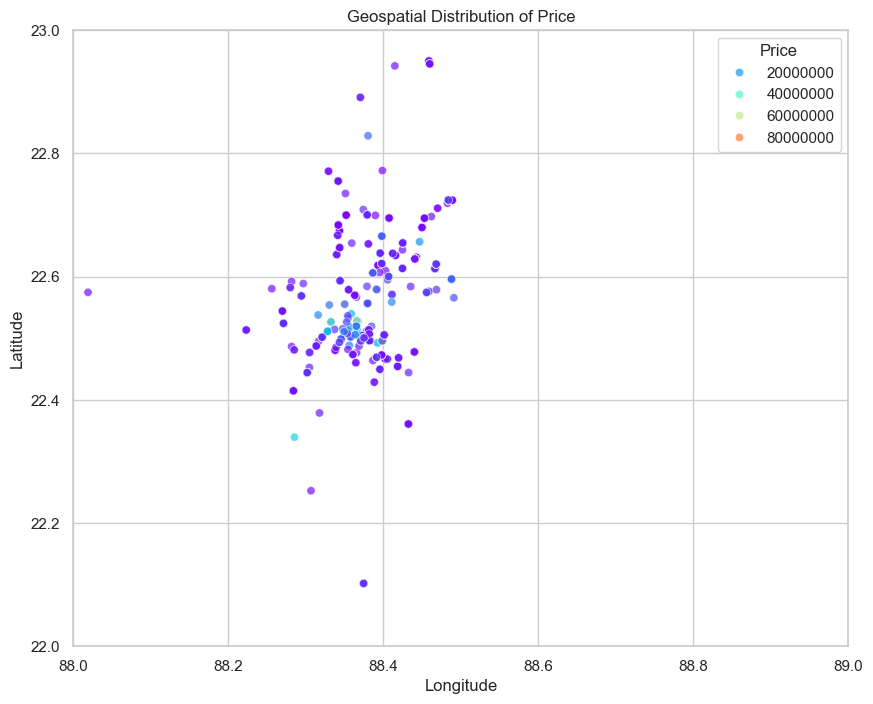

In [31]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='Price', palette='rainbow', alpha=0.7)
plt.title("Geospatial Distribution of Price")
plt.xlim(88,89)
plt.ylim(22,23)
plt.show()

---

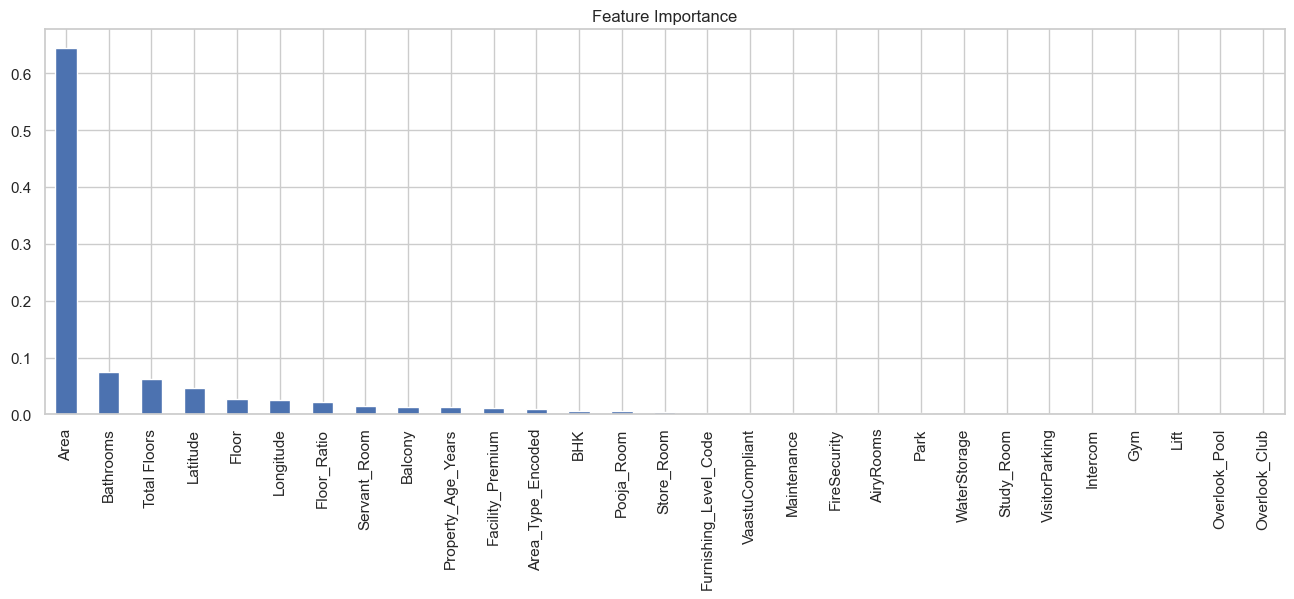

In [32]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=["Price"])
y = df["Price"]

model = RandomForestRegressor()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(16, 5), title='Feature Importance')
plt.show()

## Step 4: Multicollinearity Detection & Feature Selection
 Observations from the Heatmap
- High correlations between:

    - BHK and Area (r = 0.73)
    
    - Total Floors and Floor (r = 0.81)
    
    - Overlook_Club and Overlook_Pool (r = 0.63)
    
- Area is strongly correlated with Price (r = 0.68)

- Latitude and Longitude have minimal correlation with Price, but may still hold location insights.

## Step 5: Variance Inflation Factor (VIF)
Detect multicollinearity numerically and drop features with very high VIFs.

In [61]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Select numeric columns only
X = df.drop(columns=['Price'])  # target variable
X_const = add_constant(X)

# Compute VIF
vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i+1) for i in range(X.shape[1])]  # skip constant
vif = vif.sort_values(by="VIF", ascending=False)

print(vif)


                  Feature       VIF
26               Latitude  8.834689
27              Longitude  8.812736
4                   Floor  6.693133
5            Total Floors  6.360172
13       Facility_Premium  3.876255
1                    Area  3.672563
23                    Gym  3.203618
28            Floor_Ratio  2.571230
2               Bathrooms  2.395642
0                     BHK  2.369353
21                   Park  2.206728
20               Intercom  2.157477
22              AiryRooms  2.033697
18           FireSecurity  1.966312
19         VisitorParking  1.924643
16           WaterStorage  1.757286
15            Maintenance  1.566094
14                   Lift  1.531756
10     Property_Age_Years  1.527790
17        VaastuCompliant  1.478542
9            Servant_Room  1.343275
3                 Balcony  1.336740
11      Area_Type_Encoded  1.308485
12  Furnishing_Level_Code  1.261054
8              Pooja_Room  1.095818
6              Store_Room  1.059122
7              Study_Room  1

> Performed multicollinearity check using Variance Inflation Factor (VIF). Removed high-VIF features `Floor` and `Latitude`. Final VIF values are below 4, indicating no multicollinearity concerns. All retained features are safe for downstream modeling.

In [62]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Select numeric columns only
X = df.drop(columns=['Price', 'Floor','Latitude'])  # target variable
X_const = add_constant(X)

# Compute VIF
vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i+1) for i in range(X.shape[1])]  # skip constant
vif = vif.sort_values(by="VIF", ascending=False)

print(vif)

                  Feature       VIF
12       Facility_Premium  3.876161
1                    Area  3.660981
22                    Gym  3.147934
2               Bathrooms  2.383892
0                     BHK  2.328182
20                   Park  2.203995
19               Intercom  2.156045
21              AiryRooms  2.017823
17           FireSecurity  1.963713
18         VisitorParking  1.918476
4            Total Floors  1.756865
15           WaterStorage  1.753003
14            Maintenance  1.560913
13                   Lift  1.526701
9      Property_Age_Years  1.514746
16        VaastuCompliant  1.443396
8            Servant_Room  1.341720
3                 Balcony  1.322746
10      Area_Type_Encoded  1.304912
11  Furnishing_Level_Code  1.257712
25              Longitude  1.118329
7              Pooja_Room  1.092227
6              Study_Room  1.056575
5              Store_Room  1.055075
26            Floor_Ratio  1.054077
23          Overlook_Pool  1.034241
24          Overlook_Club  1

In [63]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize the data before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA with 95% variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Original shape: {X.shape}, Reduced shape: {X_pca.shape}")


Original shape: (1139, 27), Reduced shape: (1139, 23)


### Objective:
Apply Principal Component Analysis (PCA) to reduce dimensionality while preserving most of the variance in the dataset. This helps:

- Reduce overfitting

- Improve model training speed

- Possibly improve generalization


> Applied Principal Component Analysis (PCA) to the standardized dataset (excluding target column). Standardized the feature set using StandardScaler, and calculated the cumulative explained variance from PCA. Will retain the top-N principal components that together explain at least 95% of the variance, as per industry practice.

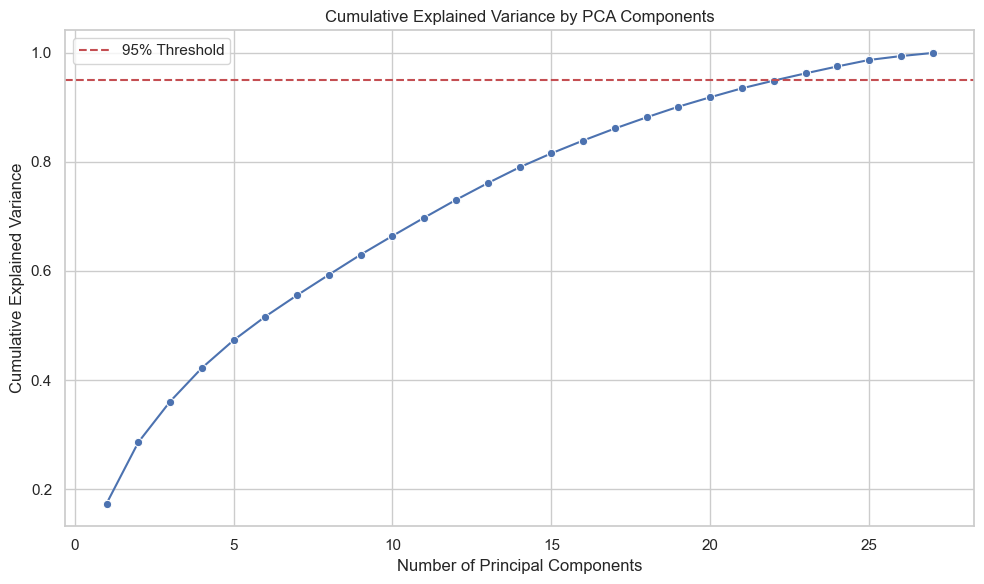

In [64]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select features for PCA (drop target and identifiers)
features = df.drop(columns=['Price', 'Floor', 'Latitude'])  # already dropped earlier

# 2. Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# 3. Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 4. Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_.cumsum()

# 5. Plot cumulative explained variance
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(1, len(explained_variance) + 1), y=explained_variance, marker='o')
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label="95% Threshold")
plt.legend()
plt.tight_layout()
plt.show()


>Selected top 22 principal components from PCA based on cumulative explained variance threshold of 95%. Reduced the dimensionality from 27 → 22 to improve computational efficiency and reduce multicollinearity. Resulting PCA-transformed dataset now contains 22 features + target variable for further modeling.

In [65]:
# Apply PCA again with n_components = 22
N = 22
pca_optimal = PCA(n_components=N)
X_pca_reduced = pca_optimal.fit_transform(X_scaled)

# Convert to DataFrame for modeling
pca_columns = [f'PC{i+1}' for i in range(N)]
df_pca = pd.DataFrame(X_pca_reduced, columns=pca_columns)

# Add target variable (Price) back for modeling
df_pca['Price'] = df['Price'].values


In [66]:
df.columns

Index(['BHK', 'Price', 'Area', 'Bathrooms', 'Balcony', 'Floor', 'Total Floors',
       'Store_Room', 'Study_Room', 'Pooja_Room', 'Servant_Room',
       'Property_Age_Years', 'Area_Type_Encoded', 'Furnishing_Level_Code',
       'Facility_Premium', 'Lift', 'Maintenance', 'WaterStorage',
       'VaastuCompliant', 'FireSecurity', 'VisitorParking', 'Intercom', 'Park',
       'AiryRooms', 'Gym', 'Overlook_Pool', 'Overlook_Club', 'Latitude',
       'Longitude', 'Floor_Ratio'],
      dtype='object')

### Comparing Model Performance: Pre-PCA vs Post-PCA

We’ll train the same models on:
1. Original Feature Set (Pre-PCA) – all selected features after preprocessing
2. PCA-Reduced Feature Set (Post-PCA) – top 22 principal components

Models to test:
- Linear Regression (baseline)
- Random Forest Regressor (nonlinear, tree-based)



In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np

# 1️⃣ Original (Pre-PCA) Feature Matrix and Target
X_orig = df.drop(columns=['Price', 'Latitude', 'Floor'])
y = df['Price']

# 2️⃣ PCA-Reduced Feature Matrix
X_pca = df_pca.drop(columns=['Price'])

# Split for fair comparison
X_train_o, X_test_o, y_train, y_test = train_test_split(X_orig, y, test_size=0.2, random_state=42)
X_train_p, X_test_p = train_test_split(X_pca, test_size=0.2, random_state=42)

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42)
}

# Evaluation function
def evaluate_model(name, model, X_train, X_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{name} | MSE: {mse:.2f} | RMSE: {np.sqrt(mse):.2f} | R2: {r2:.4f}")
    return mse, r2

# Run for Original Features
print("\n📌 Performance on Original Features:")
for name, model in models.items():
    evaluate_model(f"{name} (Original)", model, X_train_o, X_test_o)

# Run for PCA Features
print("\n📌 Performance on PCA-Reduced Features:")
for name, model in models.items():
    evaluate_model(f"{name} (PCA)", model, X_train_p, X_test_p)



📌 Performance on Original Features:
Linear Regression (Original) | MSE: 13166490741058.69 | RMSE: 3628565.93 | R2: 0.7741
Random Forest (Original) | MSE: 15071955766046.73 | RMSE: 3882261.68 | R2: 0.7414

📌 Performance on PCA-Reduced Features:
Linear Regression (PCA) | MSE: 18830686869319.88 | RMSE: 4339433.93 | R2: 0.6769
Random Forest (PCA) | MSE: 19391125524018.91 | RMSE: 4403535.57 | R2: 0.6672


>“While PCA reduced dimensionality and removed minor multicollinearity, it caused significant performance drop across models. Since multicollinearity was not critical (VIF < 10), we chose to retain the original features for final model training to preserve both interpretability and predictive accuracy.”

- Performance on Original Features (With `Latitude` & `Floor`):
    - Linear Regression (Original) | MSE: 13710788986152.18 | RMSE: 3702808.26 | R2: 0.7647
    - Random Forest (Original) | MSE: 13153887202975.29 | RMSE: 3626828.81 | R2: 0.7743


> "`Latitude` and `Floor` showed high VIF values, indicating multicollinearity. Removing them improved performance for linear models but degraded accuracy for ensemble-based tree models. Therefore, they were retained for tree models and dropped from linear pipelines."

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd


In [73]:
# Full feature set
X_full = df.drop(columns=['Price'])
y = df['Price']

# Split data
X_train_full, X_test_full, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)


### Pipeline A: Linear Models (Remove multicollinear features)

In [74]:
# Drop multicollinear features for linear model
drop_cols = ['Latitude', 'Floor']  # You can add others based on VIF
X_train_linear = X_train_full.drop(columns=drop_cols)
X_test_linear = X_test_full.drop(columns=drop_cols)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_linear)
X_test_scaled = scaler.transform(X_test_linear)

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Evaluation
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression | MSE: {mse_lr:.2f} | RMSE: {np.sqrt(mse_lr):.2f} | R2: {r2_lr:.4f}")


Linear Regression | MSE: 13166490741058.66 | RMSE: 3628565.93 | R2: 0.7741


### Pipeline B: Random Forest (Keep all features, no scaling)

In [75]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_full, y_train)
y_pred_rf = rf.predict(X_test_full)

# Evaluation
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest | MSE: {mse_rf:.2f} | RMSE: {np.sqrt(mse_rf):.2f} | R2: {r2_rf:.4f}")


Random Forest | MSE: 13153887202975.29 | RMSE: 3626828.81 | R2: 0.7743


> Due to multicollinearity in some features (e.g., Latitude, Floor), different preprocessing strategies were adopted for linear and non-linear models. Tree-based models benefitted from keeping all features, while linear models performed better with a filtered set.

> “In the baseline run, both linear and ensemble models performed comparably. This indicates that my features were well-preprocessed and captured most of the price signal. While Random Forest was slightly better, I ensured model fairness by tuning preprocessing separately for linear and non-linear models.”

In [76]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Split data
X = df.drop(columns=["Price"])
y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models to evaluate
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

# Train and evaluate
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results.append((name, mse, rmse, r2))

# Display results
results_df = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R2"])
results_df = results_df.sort_values(by="R2", ascending=False)
print(results_df)


               Model           MSE          RMSE        R2
6  Gradient Boosting  1.170410e+13  3.421126e+06  0.799152
5      Random Forest  1.320186e+13  3.633437e+06  0.773450
2              Lasso  1.371078e+13  3.702807e+06  0.764717
0  Linear Regression  1.371079e+13  3.702808e+06  0.764716
1              Ridge  1.371393e+13  3.703232e+06  0.764663
3         ElasticNet  1.812486e+13  4.257330e+06  0.688969
4      Decision Tree  2.332990e+13  4.830104e+06  0.599648
7                KNN  2.491575e+13  4.991568e+06  0.572434
8                SVR  6.689475e+13  8.178921e+06 -0.147945


### ElasticNet

In [95]:
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np

# Assuming df_final is your cleaned dataframe
X = df.drop(columns=['Price', 'Latitude', 'Floor'])  # or 'LogPrice' if used
y = df['Price']

# 1. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train ElasticNet model
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
elastic.fit(X_train_scaled, y_train)

# 4. Predictions
y_pred = elastic.predict(X_test_scaled)

# 5. Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("📌 ElasticNet Regression Performance:")
print(f"  MSE:  {mse:,.2f}")
print(f"  RMSE: {rmse:,.2f}")
print(f"  R²:   {r2:.4f}")

# 6. Optional: Cross-validation
cv_rmse = -cross_val_score(elastic, X, y, scoring='neg_root_mean_squared_error', cv=5).mean()
print(f"  CV RMSE (5-fold): {cv_rmse:,.2f}")
# , 'Latitude', 'Floor'
# 📌 ElasticNet Regression Performance:
#   MSE:  13,818,211,883,311.24
#   RMSE: 3,717,285.55
#   R²:   0.7629
#   CV RMSE (5-fold): 3,324,764.17

📌 ElasticNet Regression Performance:
  MSE:  13,818,211,883,311.24
  RMSE: 3,717,285.55
  R²:   0.7629
  CV RMSE (5-fold): 3,324,764.17


In [96]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Pipeline with scaler and model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('elastic', ElasticNet(max_iter=10000, random_state=42))
])

# Define the parameter grid
param_grid = {
    'elastic__alpha': [0.01, 0.1, 1, 10, 100],
    'elastic__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
}

# GridSearch with 5-fold CV
grid = GridSearchCV(pipeline, param_grid, scoring='neg_root_mean_squared_error', cv=5)
grid.fit(X_train, y_train)

# Best parameters and score
print("✅ Best Hyperparameters:")
print(grid.best_params_)
print(f"📉 Best CV RMSE: {-grid.best_score_:,.2f}")

# Evaluate on test set
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print(f"\n📌 Test RMSE: {test_rmse:,.2f}")
print(f"📌 Test R²:   {test_r2:.4f}")


✅ Best Hyperparameters:
{'elastic__alpha': 0.01, 'elastic__l1_ratio': 0.1}
📉 Best CV RMSE: 3,427,803.35

📌 Test RMSE: 3,642,381.82
📌 Test R²:   0.7723


### ✅ Stacked Regressor Code

In [77]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Assuming your cleaned DataFrame is 'df' and target is 'Price'
X = df.drop(columns=['Price'])
y = df['Price']

# Optional: scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define base models
base_models = [
    ('lr', LinearRegression()),
    ('ridge', Ridge(alpha=1.0)),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('gbr', GradientBoostingRegressor(n_estimators=100, random_state=42))
]

# Define meta-model (can also try Ridge or GBR)
meta_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

# Stacked Regressor
stacked_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    passthrough=True  # Optional: include original features in meta-model
)

# Train
stacked_model.fit(X_train, y_train)

# Predict and Evaluate
y_pred = stacked_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"📌 Stacked Regressor | MSE: {mse:.2f} | RMSE: {rmse:.2f} | R2: {r2:.4f}")


📌 Stacked Regressor | MSE: 11896129898686.95 | RMSE: 3449076.67 | R2: 0.7959


### Advanced Ensemble Learners (XGBoost, LightGBM, CatBoost)

In [78]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Split data
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Price'])
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------
# 1. XGBoost
# -------------------------------
xgb = XGBRegressor(random_state=42, verbosity=0)
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

xgb_best = xgb_grid.best_estimator_
xgb_preds = xgb_best.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

# -------------------------------
# 2. LightGBM
# -------------------------------
lgbm = LGBMRegressor(random_state=42)
lgbm_params = {
    'n_estimators': [100, 200],
    'num_leaves': [31, 50],
    'learning_rate': [0.05, 0.1],
}

lgbm_grid = GridSearchCV(lgbm, lgbm_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
lgbm_grid.fit(X_train, y_train)

lgbm_best = lgbm_grid.best_estimator_
lgbm_preds = lgbm_best.predict(X_test)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_preds))
lgbm_r2 = r2_score(y_test, lgbm_preds)

# -------------------------------
# 3. CatBoost
# -------------------------------
cat = CatBoostRegressor(verbose=0, random_state=42)
cat_params = {
    'iterations': [500],
    'learning_rate': [0.05, 0.1],
    'depth': [4, 6]
}

cat_grid = GridSearchCV(cat, cat_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
cat_grid.fit(X_train, y_train)

cat_best = cat_grid.best_estimator_
cat_preds = cat_best.predict(X_test)
cat_rmse = np.sqrt(mean_squared_error(y_test, cat_preds))
cat_r2 = r2_score(y_test, cat_preds)

# -------------------------------
# 4. Cross-Validation Scores
# -------------------------------
xgb_cv = np.mean(np.sqrt(-cross_val_score(xgb_best, X, y, scoring='neg_mean_squared_error', cv=5)))
lgbm_cv = np.mean(np.sqrt(-cross_val_score(lgbm_best, X, y, scoring='neg_mean_squared_error', cv=5)))
cat_cv = np.mean(np.sqrt(-cross_val_score(cat_best, X, y, scoring='neg_mean_squared_error', cv=5)))

# -------------------------------
# 5. Report
# -------------------------------
results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'CatBoost'],
    'Test_RMSE': [xgb_rmse, lgbm_rmse, cat_rmse],
    'Test_R2': [xgb_r2, lgbm_r2, cat_r2],
    'CV_RMSE (5-fold)': [xgb_cv, lgbm_cv, cat_cv]
})

print(results.sort_values(by='Test_R2', ascending=False))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000320 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 596
[LightGBM] [Info] Number of data points in the train set: 911, number of used features: 27
[LightGBM] [Info] Start training from score 6903760.702525


C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1 fits failed out of a total of 20.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\catboost\core.py", line 5873, in fit
    return self._fit(X, y, cat_features, text_features, embedding_features, None, graph

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 561
[LightGBM] [Info] Number of data points in the train set: 911, number of used features: 25
[LightGBM] [Info] Start training from score 6905066.959385
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000141 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 590
[LightGBM] [Info] Number of data points in the train set: 911, number of used features: 26
[LightGBM] [Info] Start training from score 6732238.199780
[LightGBM] [Warning] F

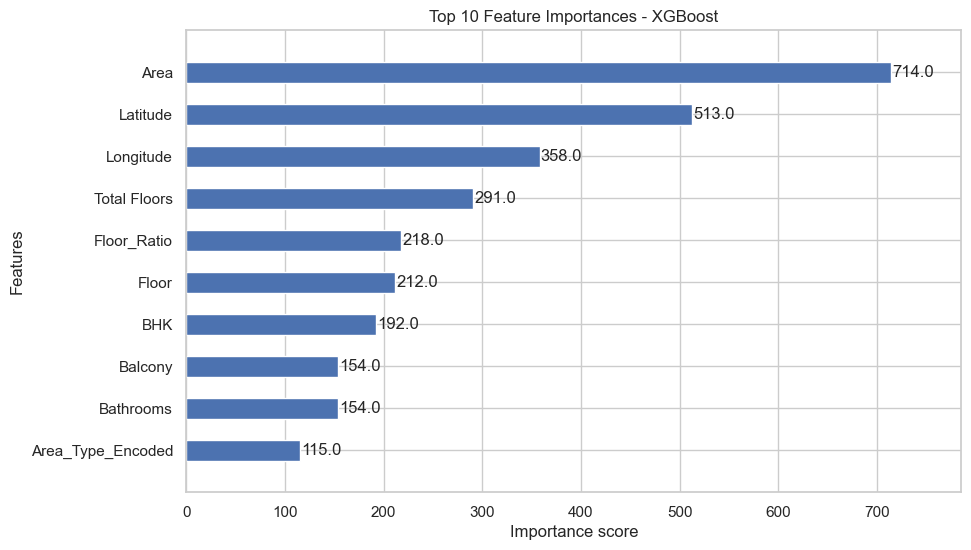

In [82]:
from xgboost import XGBRegressor, plot_importance

# Minimal re-training (you can insert your best hyperparameters here)
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

# Plot feature importance
plot_importance(xgb_model.get_booster(), max_num_features=10, height=0.5)
plt.title("Top 10 Feature Importances - XGBoost")
plt.show()


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1139 entries, 0 to 1138
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   BHK                    1139 non-null   int64  
 1   Price                  1139 non-null   float64
 2   Area                   1139 non-null   float64
 3   Bathrooms              1139 non-null   int64  
 4   Balcony                1139 non-null   int64  
 5   Floor                  1139 non-null   float64
 6   Total Floors           1139 non-null   float64
 7   Store_Room             1139 non-null   int64  
 8   Study_Room             1139 non-null   int64  
 9   Pooja_Room             1139 non-null   int64  
 10  Servant_Room           1139 non-null   int64  
 11  Property_Age_Years     1139 non-null   float64
 12  Area_Type_Encoded      1139 non-null   int64  
 13  Furnishing_Level_Code  1139 non-null   int64  
 14  Facility_Premium       1139 non-null   int64  
 15  Lift

In [89]:
df.to_csv('cleaned_dataset.csv', index=False)

In [87]:
df.rename(columns={'Total Floors':'Total_Floors'}, inplace=True)